In [7]:
!pip install 'sunpy[all]' 'numpy<1.26' natsort xarray torch codecarbon pandas

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [1]:
import numpy as np
from natsort import natsorted
import xarray as xr

import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm
from codecarbon import track_emissions

# Solar Virtual Observatory Challenge

## The Sun

<img src="https://scied.ucar.edu/sites/default/files/styles/extra_large/public/images/Interior_Sun_layers.jpg.webp?itok=MdqlQJwf" width="600">

Sun's Atmosphere:
- Photosphere
- Chromosphere
- Transition Region
- Corona

## Solar Dynamics Observatory

![](https://sdo.gsfc.nasa.gov/assets/img/site/spacecraft_detailed.jpg)

### HMI (Helioseismic and Magnetic Imager)

- Observes Photosphere
- 6173 Å filter $\rightarrow$ Fe I
- Measures Dopplershift $\rightarrow$ Plasma movement $\rightarrow$ Heliseismic activity
- Measures Poalrization and Zeeman splitting $\rightarrow$ Magnetic Field

### EVE (Extreme Ultraviolet Variability Experiment)

- Observes Sun’s corona and transition region
- Measures the solar extreme-ultraviolet (EUV)
- Important for space weather $\rightarrow$ EUV hits Earth's atmosphere

### AIA (Atmospheric Imaging Assembly)

- Observes Chromosphere, Transition Region, and Corona
- 10 different wavelenghts (in this challenge only 9)
- Investigates mechanisms that heat the corona

# Challenge

## a) A virtual observatory

### **Given**: AIA Data from 2010
### **Problem**: Prolonged exposure to intense radiation during a solar maximum has led to the degradation of 8 AIA filters onboard SDO. Only the 94 Å channel remains operational.
### **Task**: Use what you’ve learned in this school to train a deep learning model that reconstructs the missing 8 AIA channels — and help restore our multi-wavelength view of the dynamic Sun!

## b) Use `codecarbon` to optimize for the best trad-off between model performance and energy consumption

### Find a way to quantify a stopping point for training
### Optimize your hyperparameters (e.g. number of layers, batch size, ...)

# The Data

# Inspect Data

Download file locally to your computer from https://zenodo.org/records/15143847/files/all128.nc

Put it in now Google Drive next!

In [13]:
ds = xr.open_dataset('/cephfs/users/sfroese/all128.nc')

In [14]:
ds.channel

<xarray.DataArray 'channel' (channel: 9)> Size: 72B
array(['131A', '1600A', '1700A', '171A', '193A', '211A', '304A', '335A', '94A'],
      dtype=object)
Coordinates:
  * channel  (channel) object 72B '131A' '1600A' '1700A' ... '304A' '335A' '94A'

In [15]:
selected_channel = ds['DN'].sel(channel='171A')
selected_channel

<xarray.DataArray 'DN' (time: 6130, x: 128, y: 128)> Size: 402MB
[100433920 values with dtype=float32]
Coordinates:
  * time     (time) int32 25kB 0 1 2 3 4 5 6 ... 6124 6125 6126 6127 6128 6129
  * x        (x) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * y        (y) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
    channel  <U4 16B '171A'

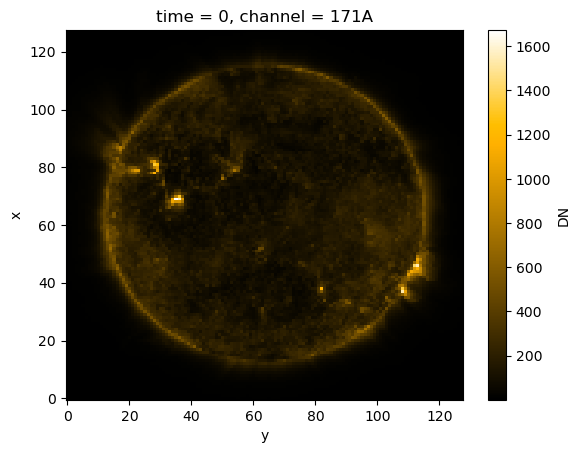

In [16]:
img = selected_channel.isel(time=0)
cmap = plt.get_cmap('sdoaia171')
img.plot(cmap=cmap)


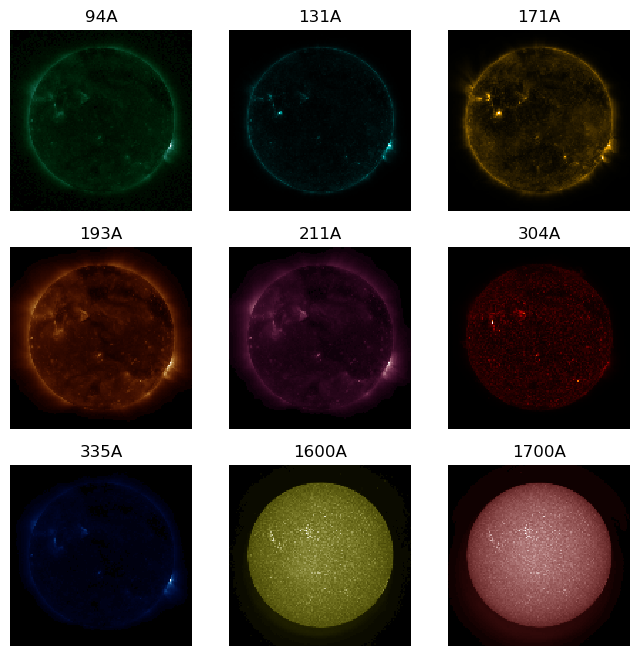

In [18]:
keys = natsorted(ds['channel'].data)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, key in zip(axes.ravel(), keys):
    data = ds['DN'].sel(channel=key).isel(time=0)
    cmap = plt.get_cmap(f'sdoaia{key[:-1]}')
    im = data.plot(cmap=cmap, ax=ax, add_colorbar=False)
    ax.set_title(key)
    ax.axis('off')

plt.show()